# Machine Learning

Update: 2026-06-21

some basic regarding machine learning, though it's not a complete list. 

note that this is my own notes following the order of `The Nuts and Bolts of Machine Learning` as part of the Google Advanced Data Analytics. i dont believe i copied anything directly so it's safe in general. 

the code part is generated with help of Gemini AI and myself,  not from the course.



------------------------------------------------------

## Naive Bayes

A Naive Bayes model is a supervised learning technique used for classification
The Naive Bayes algorithm is based on Bayes’ Theorem, an equation that can be used to calculate the probability of an outcome or class, given the values of predictor variables. This value is known as the posterior probability.


hat probability is calculated using three values: 

- The probability of the outcome overall P(A)

- The probability of the value of the predictor variable P(B)

- The conditional probability P(B|A) (Note: P(B|A) is interpreted as the probability of B, given A.)

The probability of the outcome overall, P(A), is multiplied by the conditional probability, P(B|A). This result is then divided by the probability of the predictor variable, P(B), to obtain the posterior probability. 


then we can calculate P(Bn|A) for all the classes for potential outcomes. The class with the highest resulting product is the model’s final prediction for that sample.  

### Assumption:

1. `conditional independence` : each predictor variable (different Bs in the formula) is independent from the others, conditional on the class. 
2. no predictor variable has any more predictive power than any other predictor (this is oftenly violated with real world problem, but the model may still work to some degree)

### issue with Naive Bayes

1. conditional independence assumption is rarely true 

2. the `zero frequency` issue: data has no occurrences of a class label and some value of a predictor variable together



we can use `sklearn.naive_bayes` for the coding part and severl different variants are:
- BernoulliNB:        Used for binary/Boolean features 

- CategoricalNB: 	Used for categorical features

- ComplementNB: 	Used for imbalanced datasets, often for text classification tasks

- GaussianNB:		Used for continuous features, normally distributed features

- MultinomialNB:	Used for multinomial (discrete) features

see https://scikit-learn.org/stable/modules/naive_bayes.html#naive-bayes

and from simple modeling, we can use the same metrics for evaluation


Accuracy = (TP+TN) / total
- this means how many are accurately classified
- note that accuracy is more appropriate when TP and TN are roughly equal in the data. e.g., accuracy of 95% sounds nice but it's bias and not really reflecting the performance when only 1% of the population has an disease.

Precision = TP/(TP+FP)
- How many predicted positives were actually correct
- this is helpful when the cost of a false positive is quite high and cost of FP > FP
- e.g., falsely detect manuascript acceptance email as spam


Recall = TP / (TP + FN)
- Recall measures the proportion of data points that are predicted as True, out of all the data points that are actually True (False negative is actually True...)
- This is helpful if we care about false negative and cost of FN > FP 
- e.g., falsly detect non-emergency event


F1 score = 2 * (precision * recall) / (precision + recall)

- also known as harmonic mean. F1 score can range [0, 1], with zero being the worst and one being the best.
- max of F1 score can only be mean (when precision == recall)

Naive Bayes is used as a rapid classifier, as it requires not much training time and data. This is useful when screening large amount of compounds (like millions in database), such as protein binding, toxicity prediction, or drug discovery. 

why this works? becuase chemical structures (like if there's benzene, where it is etc) is independent from other strucutures, which we can trace each groups for their probabilities for the target prediction.

---------------------------------------------------------------------------

# K-means clustering

K means clustering is an unsupervised method, which we try to cluster unlabeled data by a centroid (or a mathmatical mean). 

The "K" is the number of centroids to place into the data space and model. you need to decide the value of K (which sometime you know how many but sometimes you dont). note that you cant really know the "correct answer" unless you know the entire population. 

steps:
1. initiate by introducing random centroids into the data 
2. assign all data points to the nearest centroid
3. recalculate the centroid of each cluster based on the points assigned from step 2
4. repeat step 2 and 3 until the model converged. data assignment can change during this process

but, sometimes steps one can results in poor centroid that later steps cannot fix. so muliple models with different initiation centroids are needed. 


also, when there are too many dimensions or the cluster are long and narrow, k-means clustering can have issue to do the job properly
- K-means works the best whtn the cluster is about a circle

and note that k-means relies on the `euclidean distance`, i.e., from one point to another with a straight line, if your data groups has different scales (lets say one group has range from 1 to 100 but another is from 1 to 1000). so normalizing or standardize the data can be important!



p.s. some people also call it "K-means partitioning" but clustering is more common


we can use `sklearn.cluster.KMeans`

lets say we setup our model by `kms = KMeans(n_clusters=3, random_state=42)`

if you only want to train a model and dont need the clustering result immediately, use `kms.fit()` and this returns the model itself

but if you want to get the cluster label, use `labels = kms.fit_predict()` 

or you have to get it from `kms.labels_`  attribute 

if have trained an model already, you can use kms.predict() to see the prediction results

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Generate realistic dummy data for 3 distinct atmospheric sources
np.random.seed(42)

# Source A: Wildfire Smoke (High Levoglucosan, Low Hopane)
smoke = np.random.multivariate_normal(mean=[120, 2], cov=[[100, 0], [0, 1]], size=20)

# Source B: Traffic Exhaust (Low Levoglucosan, High Hopane)
traffic = np.random.multivariate_normal(mean=[5, 45], cov=[[5, 0], [0, 25]], size=20)

# Source C: Clean Background Air (Low Levoglucosan, Low Hopane)
background = np.random.multivariate_normal(mean=[10, 4], cov=[[10, 0], [0, 2]], size=20)

# Combine into a single un-labeled Pandas dataframe
data_matrix = np.vstack([smoke, traffic, background])
df_air = pd.DataFrame(data_matrix, columns=['Levoglucosan_ng_m3', 'Hopane_pg_m3'])

# Shuffle the rows so the model doesn't get them in order
df_air = df_air.sample(frac=1).reset_index(drop=True)

print("What the un-labeled data looks like to K-Means:")
print(df_air.head(5))

What the un-labeled data looks like to K-Means:
   Levoglucosan_ng_m3  Hopane_pg_m3
0           12.894756      4.464924
1            6.367750     41.615390
2           10.190465      7.483550
3          135.792128      2.767435
4           10.306986      5.369871


In [27]:
# 2. Initialize and fit K-Means with K=3 clusters
# n_init='auto' tells scikit-learn to pick the starting coordinates intelligently
kmeans = KMeans(n_clusters=3, n_init='auto', random_state=42)
df_air['Cluster_Label'] = kmeans.fit_predict(df_air)

# Look at the result. The model has assigned a 0, 1, or 2 to every sample!
print("\nData with automated cluster labels assigned:")
print(df_air.head(5))


Data with automated cluster labels assigned:
   Levoglucosan_ng_m3  Hopane_pg_m3  Cluster_Label
0           12.894756      4.464924              2
1            6.367750     41.615390              0
2           10.190465      7.483550              2
3          135.792128      2.767435              1
4           10.306986      5.369871              2


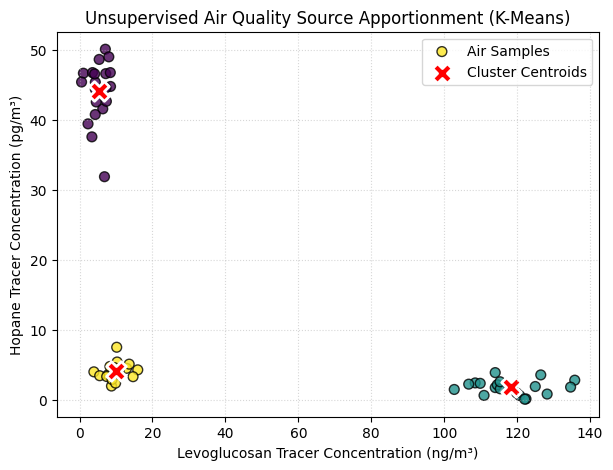

Calculated Coordinates for the 3 Chemical Archetypes (Centroids):
Cluster 0 Center -> Levoglucosan: 5.25, Hopane: 44.15
Cluster 1 Center -> Levoglucosan: 118.24, Hopane: 1.74
Cluster 2 Center -> Levoglucosan: 9.91, Hopane: 4.07


In [28]:
plt.figure(figsize=(7, 5))

# Plot the clustered data points using the automated labels for colors
scatter = plt.scatter(
    df_air['Levoglucosan_ng_m3'], 
    df_air['Hopane_pg_m3'], 
    c=df_air['Cluster_Label'], 
    cmap='viridis', 
    s=50, 
    alpha=0.8, 
    edgecolors='black',
    label='Air Samples'
)

# --- PLOTTING THE CENTROIDS ---
# kmeans.cluster_centers_ holds the calculated average coordinates of each cluster center
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    color='red', 
    marker='X', 
    s=200, 
    linewidths=2,
    edgecolors='white', 
    label='Cluster Centroids'
)

plt.title('Unsupervised Air Quality Source Apportionment (K-Means)')
plt.xlabel('Levoglucosan Tracer Concentration (ng/m³)')
plt.ylabel('Hopane Tracer Concentration (pg/m³)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()

print("Calculated Coordinates for the 3 Chemical Archetypes (Centroids):")
for i, center in enumerate(centroids):
    print(f"Cluster {i} Center -> Levoglucosan: {center[0]:.2f}, Hopane: {center[1]:.2f}")

we can see if we dont know in advance that there wer three groups and assign k = 2

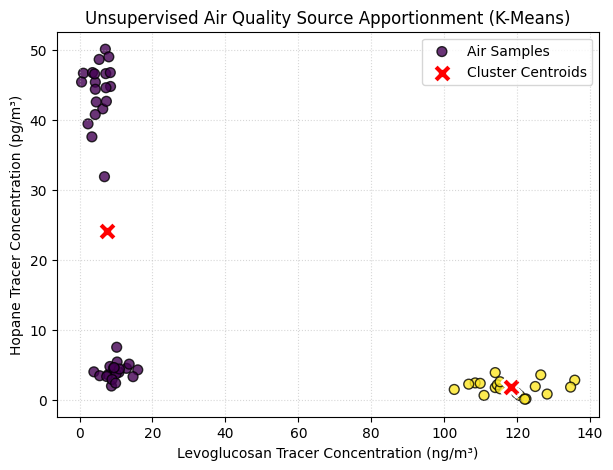

Calculated Coordinates for the 3 Chemical Archetypes (Centroids):
Cluster 0 Center -> Levoglucosan: 7.58, Hopane: 24.11
Cluster 1 Center -> Levoglucosan: 118.24, Hopane: 1.74


In [5]:
kmeans_2 = KMeans(n_clusters=2, n_init='auto', random_state=42)
df_air['Cluster_Label'] = kmeans_2.fit_predict(df_air)
plt.figure(figsize=(7, 5))

scatter = plt.scatter(
    df_air['Levoglucosan_ng_m3'], 
    df_air['Hopane_pg_m3'], 
    c=df_air['Cluster_Label'], 
    cmap='viridis', 
    s=50, 
    alpha=0.8, 
    edgecolors='black',
    label='Air Samples'
)

centroids = kmeans_2.cluster_centers_
plt.scatter(
    centroids[:, 0], 
    centroids[:, 1], 
    color='red', 
    marker='X', 
    s=200, 
    linewidths=2,
    edgecolors='white', 
    label='Cluster Centroids'
)

plt.title('Unsupervised Air Quality Source Apportionment (K-Means)')
plt.xlabel('Levoglucosan Tracer Concentration (ng/m³)')
plt.ylabel('Hopane Tracer Concentration (pg/m³)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend()
plt.show()

print("Calculated Coordinates for the 3 Chemical Archetypes (Centroids):")
for i, center in enumerate(centroids):
    print(f"Cluster {i} Center -> Levoglucosan: {center[0]:.2f}, Hopane: {center[1]:.2f}")

    

now, the issue is that we cannot really use metrics like precision/accuracy anymore since our data is not labeled and we're not predicting anything. we're only looking at the data and applying our knowledge to interprete the results.

#### but how can we really tell if the model is doing good or not?


##### inertia 
= sum of the squared distance between each observation and nearest centroid
- this is measurement of how close a data point from centroid wihtin a cluster (or how dispersed datapoints are within a cluster)
- this is a _intra-cluster_ metric
- lower inertia = less distance between points and the centroid
- inertia can be 0 if data points overlap... 
- usually more k = lower inertia, but more might not improve much so need to decide where the best k is

#### silhouette score
- the mean of silhouette coefficients of all observations in the model (including all clusters!)
- silhouette coefficients (of an observation) = (b-a)/max(a,b)
    a is the mean distance from the observation to _all other observations in the cluster_
    b is the mean distance from that observation to each observation in the _next closest cluster_

- this is a measure of how well a point is seperated from other cluster
1. positive silhouette score = well seperated from other cluster
2. silhouette score close to 0 means it's near the middle or boundary of two cluster
3. negative silhouette score means it's probably on the wrong cluster since it's closer to other cluster

- usually choose a k that max silhouette score 

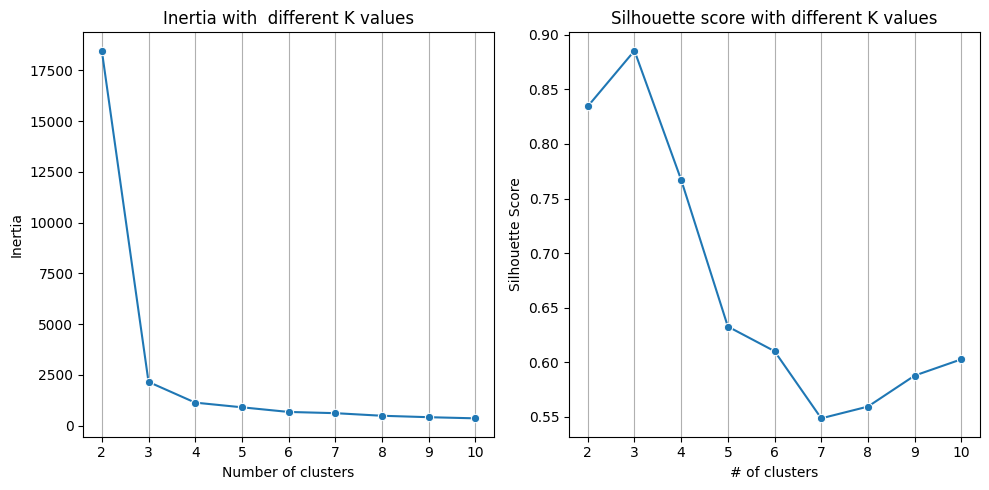

In [42]:
from sklearn.metrics import silhouette_score
import seaborn as sns

n_clusters = [i for i in range(2, 11)]

inertia = []
sil_score = []
for n in n_clusters:
    kms = KMeans(n_clusters=n, random_state=42)
    kms.fit(df_air)
    inertia.append(kms.inertia_)
    sil_score.append(silhouette_score(df_air, kms.labels_))


fig, axes = plt.subplots(1,2,figsize=(10,5 ))
sns.lineplot(x=n_clusters, y=inertia, marker = 'o', ax= axes[0])
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Inertia with  different K values")
axes[0].grid(axis='x')



sns.lineplot(x=n_clusters, y=sil_score, marker = 'o', ax= axes[1])
axes[1].set_xlabel("# of clusters")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette score with different K values")
axes[1].grid(axis='x')
plt.tight_layout()
plt.show()

as we can see that from K =2 to K=3 we get a massive improvement in the inertia and higer sihouette score. this means that k=3 is probably the best for this dataset

-------------------------------------------------------

# Tree-base modeling

- supervised classification or prediction
- no assumptions required about the data


technically it's more about growing a `decision tree` where nodes are made based on the data categories or continuous numbers ranges.

all tree starts with a _root node_ to layers of decision nodes, then finally reach the end point called _leaf node_. 


when data is splitted by a decision node, since it's labeled data, we can check the split result after a node. in the perfect world, if we have two groups, then we should see a perfect split of data. however, this usually wont happen, and thus we can measure the _impurity_, or the data that are present in the other dataset.

usully the lowest impurity variable is chosen for the node.


there are also lots of hyder parameter for building or optimize the tree, such as

- max depth: how long the tree can get (`max_depth`). this can be `None` which allow it to grow until other limits are met
- min sample: min number of sample remain in a leaf node (`min_samples_leaf`) or split into (`min_samples_split`)

find more in https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html



# model validation

this is more of an extra step to help you make decision about model selection or tuning the models.
common ways include 

#### split data into training, validation, and testing set
this is most common if the data size is large

#### cross validation
this is more complex but imagine we can split the data into several sets. each time we leave one set to test and use the others for training. the next time another set is hold and the process loops continue until we iterate all the combinations.

This is good if you want better prediction, but at the cost of computation power and time, and thus not good for large data


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
decision_tree = DecisionTreeClassifier() #input random_state if needed

decision_tree.fit(X_train, y_train)
dt_pred = decision_tree.predict(X_test)

plot_tree(decision_tree, max_depth=2, fontsize=14, feature_names=X.columns)

importances = decision_tree.feature_importances_

forest_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)

## Bootstrap aggregation

one issue decision tree model can encounter is overfitting especially if higher depth is allowed (i.e., the model may capture more noise in the training data = poor generalization to other data). 

one thing we can do is ensemble, or we traing multiple models and aggregate the output later to form the final result. 

but... if we use the exact same training dataset, then there might be too much correlation between the errors. 

#### _solution = bagging_ or (Bootstrap AGGregatING)


- `bootstrapping` referring to the process of sampling with replcement. some data are not selected or replaced by another data point and repeated. 
- `aggregation` refers to that we aggregate all the predictions to determine the final prediction. this helps to reduce the variance from a single model




In sklearn, there's the base `BaggingRegressor` and `BaggingClassifier`
- we can use any machine learning model as the " estimator"

read more here: 

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingRegressor.html

#### Random Forest

random forest is a specific type of bagging model, and only uses decision tree as the base estimator with highly optimized process.

- we now get a "forest", i.e., a good number of individual decision trees. each tree votes and the majority is delivered by the forest (or average for regression)

- as we mentioned before, we cannot use the same dataset for each tree. so Bootstrap Aggregating is used. Each tree only gets a random subset of the training data, so each tree may have different set of features in the dataset. the key difference is that, normal bagging process split the data at the begining. however, each tree in random forest gets a random subset of the rows and also at __every single node split__, it only considers a random subset of feature. 

- and since there's no single tree sees the entire data and there's no way a tree can overfit the training data. and in fact a single tree is actually __underfitting__ and can be highly bias. but with a forest this results a powerful tool


- computational wise it's not slow since each training may happen in parellel (thanks to GPU). and we're not looking into a big dataset all at once (compared to a single decision tree)



##### tuning a random forest model hyperparameter


similar to  decision tree model, we can use `max_depth` and `min_samples_leaf`
- `min_samples_splot` : control the threshold which a node becomes a leaf

we can also control the "forest" part 
- `max_features`: the number of features that each tree can take
- `n_estimators`: the number of individual tree. usually the performance will platue at some point


read more here: 
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html










we could use `GridSearchCV` to test several parameters and find the best one

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=0)
cv_params = {'max_depth': [2,3,4,5, None], 
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'max_features': [2,3,4],
             'n_estimators': [75, 100, 125, 150]
             }  

scoring = {'accuracy', 'precision', 'recall', 'f1'}

grid_search  = GridSearchCV(rf, cv_params, scoring=scoring, cv=5, refit='f1')
print(grid_search .best_params_)
print(grid_search .best_score_)

once you trained the model, you may want to save it for next time. we can use the package `pickle` for this purpose

(note that pickle can save quite a few different data format as well)


In [ ]:
import pickle
path = "" # path is empty but you should put the actual folder path you want to save to here
with open(path + 'rf_cv_model.pickle', 'wb') as w:
    pickle.dump(grid_search , w)

next time, we can get the trained data with `pickle.load()`

In [ ]:
with open(path + 'rf_cv_model.pickle', 'rb') as to_read:
    grid_search  = pickle.load(to_read)

now we have the model, but we need to validate it!


the training data is usually splitted from the overall dataset by `train_tes_split`, which we get x and y for training and testing. 

Now, we want to further split the training data into training and validation set by the same function

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, 
                                            stratify=y_train, random_state=42)



but wait. `GridSearchCV` will automatically split the data into k folds (by default 5), then train on k-1 fold then evaluate on the remaining, and repeat for all. 

we could tell it to use the training and validation set we split by `train_test_split` about which row to use.

In [ ]:
from sklearn.model_selection import PredefinedSplit


# method 1: simple indexing 

split_index = [0 if x in X_val.index else -1 for x in X_train.index]
custom_split = PredefinedSplit(split_index)

# method 2: might be faster with numpy if data is large
# 1. Start by marking everything as training (-1)
split_index = np.full(X_train.shape[0], -1)

# 2. Find the integer position of the validation rows and set them to 0
val_indices = X_train.index.get_indexer(X_val.index)
split_index[val_indices] = 0

custom_split = PredefinedSplit(split_index)



#-------------------- same as before for GridSearchCV --------------------#

rf = RandomForestClassifier(random_state=0)
cv_params = {'max_depth': [2,3,4,5, None], 
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'max_features': [2,3,4],
             'n_estimators': [75, 100, 125, 150]
             }  
scoring = {'accuracy', 'precision', 'recall', 'f1'}
rf_val = GridSearchCV(rf, cv_params, scoring=scoring, cv=custom_split, refit='f1')
rf_val.fit(X_train, y_train)
print(rf_val.best_params_)

sometimes `GridSearchCV` may not be the best way as it's a "brutal force" way to evalute every possible combinations, which can be computational expensive when you have several parameters and several values to play with. 

alternatively, there are other method to use  (but we wont dig into here)

- `RandomizedSearchCV`: this will only randomly selects a fixed number of combinations (by passing `n_iter`)

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html

<br>

- `HalvingGridSearchCV` : instead of the entire training data, it will still train in all combinations but with a fraction of the data only 

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.HalvingGridSearchCV.html

------------------------------------------------------


`Boosting` refers to having ensemble of weak learners in sequent, which each consecutive learner tries to correct the errors from the one before. 

# AdaBoost (Adaptive boosting)

adaboost uses tree-base technique, similar to random forest. it increase the weight of incorrectly predicted data in the previous tree, and decreases those as right. the process continue until reaching the maximum depth or get everything right. once every tree is built, the results are aggregated to the final prediction. 

this is similar to random forest:
- it's a ensembling technique
- aggregating is use from weak learners
- ensemble provide less variance and bias
- no need to normalize and robust to outliers 

the difference:
- random forest is in parellel, but boosting is in sequence
- random forest is decision tree only, but boosting can be any 
- unlike random forest training can be done in parellel for individual trees, adaboost cannot since we have to do the training process in sequence. this is not good for gigantic data comapred to bagging strategy.


# Gradient boosting 
unlike adaboost which works on the training data for all learners, gradient boosting has the learners in sequence which is built to predict the residual errors of the model preceded it. 

1. we train _learner 1_ to do the prediction based on the training data _X_, make the prediction and get _predicted\_y_. we can get _error\_1_ by 

&emsp;&emsp; learner_1.fit(X,y)

&emsp;&emsp; predicted_y = learner_1.predict(X)

&emsp;&emsp; error_1 = y - predicted_y

2.  use _learner\_2_  that trained on _X_ still but with _error\_1_, then we get _predicted\_error\_1_, the we can calcualte the "error of error" _error\_2_, which is 


&emsp;&emsp; learner_2.fit(X,error_1)

&emsp;&emsp; _predicted\_error\_1_ = learner_2.predict(X)

&emsp;&emsp; _error\_2_ = _error\_1_ - _predicted\_error\_1_

3. this process goes on until we reach the predefined depth. then the final prediction is sum by 

&emsp;&emsp; Final prediction = learner_1.predict(new_X) + learner_2.predict(new_X) + .... + learner_n.predict(new_X)


<br>

now ensemble that uses `gradient boosting` is called `gradient boosting machine` or `GBMs`

this method has advantage of:
- high accuracy
- scallable to large dataset
- fine with missing value which able to provide some information
- tree base = no need to normalize and robust to outliers 

disadvantage:
- lots of hyperperameters = time consuming for tuning
- hard to interprete (only show how important feature is compared to others without coefficient). 
- difficult for extrapolation (not good for data outside of data range)
- prone to overfitting ()